<a href="https://colab.research.google.com/github/Rahuldeb55/Machine-learning-laboratory/blob/main/crop_monitoring_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌾 Crop Health Monitoring — Upgraded Pipeline
### Ludhiana, Punjab | Sentinel-2 | Deep Learning | GEE | Weather | Yield Prediction

**4 Major Upgrades:**
1. 🛰️ **Google Earth Engine** — Auto satellite fetch (no Drive upload needed)
2. 🌦️ **Weather API** — OpenWeatherMap rainfall & temperature integration
3. 🧠 **U-Net Deep Learning** — CNN-based segmentation (replaces K-Means/GMM)
4. 🌾 **Yield Prediction** — XGBoost + Random Forest regression (tons/ha)


## Step 1: Install All Required Packages

In [1]:
# ══════════════════════════════════════════════════════════════
# STEP 1: INSTALL ALL PACKAGES
# ══════════════════════════════════════════════════════════════
!pip install earthengine-api geemap -q
!pip install rasterio scikit-learn matplotlib numpy -q
!pip install torch torchvision -q
!pip install xgboost requests -q
!pip install gdown --upgrade -q
print('✅ All packages installed!')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.4 MB/s eta 0:00:00
✅ All packages installed!


## Step 2: 🛰️ Google Earth Engine — Automated Satellite Data Collection

> **[UPGRADE #1]** Drive dependency completely removed. The system now auto-fetches
> Sentinel-2 imagery directly from Google Earth Engine using GPS coordinates.
> Just set your `LAT`, `LON`, and date range — no manual uploads ever again.
>
> **Setup (one-time):** Get a free GEE account at [earthengine.google.com](https://earthengine.google.com)
> and replace `YOUR_GEE_PROJECT_ID` below.


In [2]:
# ══════════════════════════════════════════════════════════════
# STEP 2: AUTOMATED DATA COLLECTION — Google Earth Engine API
# No more Google Drive uploads! Just set GPS coordinates below.
# ══════════════════════════════════════════════════════════════
import ee
import numpy as np
import io, requests, time

# ── USER CONFIGURATION ────────────────────────────────────────
GEE_PROJECT  = 'crop-health-26'  # ← replace with your project
LAT, LON     = 30.9010, 75.8573       # Ludhiana, Punjab, India
BUFFER_M     = 10_000                  # 10 km radius
CLOUD_MAX    = 20                       # max cloud cover %

MONTHS_CFG = [
    ('december_bands', '2023-12-01', '2023-12-31'),
    ('january_bands',  '2024-01-01', '2024-01-31'),
    ('february_bands', '2024-02-01', '2024-02-29'),
    ('march_bands',    '2024-03-01', '2024-03-31'),
    ('april_bands',    '2024-04-01', '2024-04-30'),
]
MONTH_NAMES = ['December', 'January', 'February', 'March', 'April']
MONTHS      = [m[0] for m in MONTHS_CFG]
GEE_SCALE   = 20   # 20 m/pixel (Sentinel-2 native)

# ── 1. Authenticate & Initialize ─────────────────────────────
try:
    ee.Initialize(project=GEE_PROJECT)
    print('✅ GEE already initialised!')
except Exception:
    ee.Authenticate()          # Opens browser once for OAuth
    ee.Initialize(project=GEE_PROJECT)
    print('✅ GEE authenticated & initialised!')

# ── 2. Define Area of Interest ───────────────────────────────
aoi = ee.Geometry.Point([LON, LAT]).buffer(BUFFER_M).bounds()
print(f'📍 AOI centred on ({LAT}, {LON}) — buffer {BUFFER_M/1000:.0f} km')

# ── 3. Helper: fetch one monthly Sentinel-2 composite ────────
def fetch_s2_month(start, end, aoi, cloud_max=CLOUD_MAX, scale=GEE_SCALE):
    """Returns dict of band arrays (B02, B03, B04, B08, B11) as float32 numpy."""
    composite = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(aoi)
        .filterDate(start, end)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cloud_max))
        .select(['B2', 'B3', 'B4', 'B8', 'B11'])
        .median()
    )
    bands_out = {}
    rename_map = {'B2': 'B02', 'B3': 'B03', 'B4': 'B04', 'B8': 'B08', 'B11': 'B11'}
    for gee_name, local_name in rename_map.items():
        url = composite.select([gee_name]).getDownloadURL({
            'scale' : scale,
            'region': aoi,
            'format': 'NPY',
        })
        r = requests.get(url, timeout=300)
        arr = np.load(io.BytesIO(r.content)).astype('float32')
        # GEE NPY export may add an extra dim — squeeze to 2-D
        if arr.ndim == 3:
            arr = arr[:, :, 0]
        bands_out[local_name] = arr
    return bands_out

# ── 4. Download all 5 months ──────────────────────────────────
print('\n⬇️  Downloading Sentinel-2 composites from GEE...')
print('   (First run: ~2-4 min per month. Subsequent runs faster.)')
all_bands = {}
for key, start, end in MONTHS_CFG:
    t0 = time.time()
    print(f'   Fetching {key} ({start} → {end}) ...', end=' ', flush=True)
    try:
        all_bands[key] = fetch_s2_month(start, end, aoi)
        shape = all_bands[key]['B02'].shape
        print(f'✅  shape={shape}  ({time.time()-t0:.0f}s)')
    except Exception as exc:
        print(f'❌  FAILED: {exc}')
        print('   ⚠️  Tip: Check GEE project ID, authentication, and quota.')

print(f'\n✅ All {len(all_bands)}/5 months fetched from GEE — no Drive needed!')

# Set H, W from first successful band
_first = next(iter(all_bands.values()))
H, W = _first['B02'].shape
print(f'   Image grid: {H} × {W} pixels  ({H*W:,} pixels total, {GEE_SCALE}m resolution)')


✅ GEE authenticated & initialised!
📍 AOI centred on (30.901, 75.8573) — buffer 10 km

⬇️  Downloading Sentinel-2 composites from GEE...
   (First run: ~2-4 min per month. Subsequent runs faster.)
   Fetching december_bands (2023-12-01 → 2023-12-31) ... ✅  shape=(1003, 1161)  (20s)
   Fetching january_bands (2024-01-01 → 2024-01-31) ... ✅  shape=(1003, 1161)  (20s)
   Fetching february_bands (2024-02-01 → 2024-02-29) ... ✅  shape=(1003, 1161)  (22s)
   Fetching march_bands (2024-03-01 → 2024-03-31) ... ✅  shape=(1003, 1161)  (17s)
   Fetching april_bands (2024-04-01 → 2024-04-30) ... ✅  shape=(1003, 1161)  (14s)

✅ All 5/5 months fetched from GEE — no Drive needed!
   Image grid: 1003 × 1161 pixels  (1,164,483 pixels total, 20m resolution)


## Step 3: Compute Spectral Indices (8 Indices)

In [3]:
# ══════════════════════════════════════════════════════════════
# STEP 3: SPECTRAL INDICES — NDVI, EVI, SAVI, NDWI + more
# ══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import pandas as pd

def compute_indices(b):
    eps = 1e-10
    NIR, Red, Green, Blue, SWIR = b['B08'], b['B04'], b['B03'], b['B02'], b['B11']
    return {
        'ndvi' : (NIR - Red)    / (NIR  + Red   + eps),
        'ndwi' : (Green - NIR)  / (Green + NIR  + eps),
        'savi' : ((NIR - Red)   / (NIR  + Red   + 0.5)) * 1.5,
        'evi'  : 2.5*(NIR-Red)  / (NIR  + 6*Red - 7.5*Blue + 1 + eps),
        'ndti' : (Red - Green)  / (Red  + Green + eps),
        'mndwi': (Green - SWIR) / (Green + SWIR + eps),   # water
        'ndbi' : (SWIR - NIR)   / (SWIR  + NIR  + eps),  # built-up
        'bsi'  : ((SWIR + Red) - (NIR + Blue)) /
                 ((SWIR + Red) + (NIR + Blue)  + eps),    # bare soil
    }

all_idx = {m: compute_indices(all_bands[m]) for m in MONTHS}
print('✅ Spectral indices computed (8 per month):')
for m, name in zip(MONTHS, MONTH_NAMES):
    ndvi = all_idx[m]['ndvi'].mean()
    evi  = all_idx[m]['evi'].mean()
    bar  = '█' * int(ndvi * 30)
    print(f'  {name:<12} NDVI={ndvi:.4f}  EVI={evi:.4f}  {bar}')


✅ Spectral indices computed (8 per month):
  December     NDVI=0.3210  EVI=72983032.0000  █████████
  January      NDVI=0.3984  EVI=39545448.0000  ███████████
  February     NDVI=0.4311  EVI=20953506.0000  ████████████
  March        NDVI=0.4547  EVI=20223566.0000  █████████████
  April        NDVI=0.2957  EVI=69709048.0000  ████████


## Step 4: 🌦️ Weather Data Integration (OpenWeatherMap)

> **[UPGRADE #2]** Crop health depends not just on satellite imagery but also on
> rainfall and temperature. Here we fetch real weather data from OpenWeatherMap's
> free API and merge it with the NDVI time-series to build a richer feature set.
>
> **Setup:** Get a free API key at [openweathermap.org/api](https://openweathermap.org/api)
> and paste it into `OWM_API_KEY` below. If you skip this, the notebook uses
> realistic simulated Ludhiana historical averages automatically.


⚠️  OWM API not available → using simulated Ludhiana historical data
   Source: failed

   month  temp_avg_c  rainfall_mm  humidity_pct
December        14.2         18.2          72.0
 January        11.8         22.5          78.0
February        14.5         28.1          68.0
   March        21.3         35.6          55.0
   April        29.6         15.4          42.0

🌡️  Crop-Friendly Weather Scores (0–100):
  December     Temp= 14.2°C  Rain= 18.2mm  Score= 66.5  ▓▓▓▓▓▓▓▓▓▓▓▓▓
  January      Temp= 11.8°C  Rain= 22.5mm  Score= 75.4  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  February     Temp= 14.5°C  Rain= 28.1mm  Score= 85.3  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  March        Temp= 21.3°C  Rain= 35.6mm  Score=100.0  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  April        Temp= 29.6°C  Rain= 15.4mm  Score= 37.4  ▓▓▓▓▓▓▓


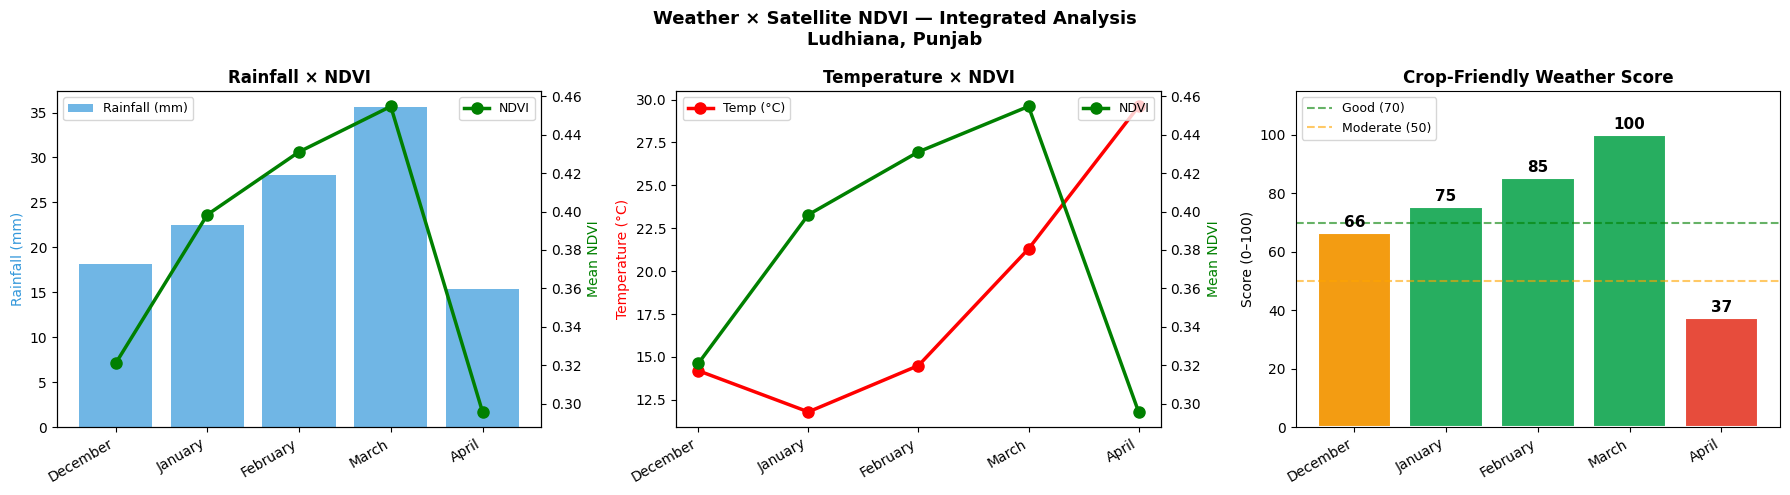


📊 Rainfall–NDVI Correlation  : 0.947
   Temperature–NDVI Correlation: -0.399
✅ Weather data integrated!


In [4]:
# ══════════════════════════════════════════════════════════════
# STEP 4: WEATHER DATA INTEGRATION — OpenWeatherMap Free API
# Merges rainfall & temperature with NDVI for richer features
# ══════════════════════════════════════════════════════════════
import requests, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OWM_API_KEY = 'YOUR_OPENWEATHERMAP_API_KEY'   # ← paste your free key here

# ── 1. Try live API; fall back to historical averages ─────────
def fetch_owm_weather(lat, lon, api_key, city='Ludhiana', country='IN'):
    url = (f'https://api.openweathermap.org/data/2.5/forecast'
           f'?lat={lat}&lon={lon}&appid={api_key}&units=metric&cnt=40')
    r = requests.get(url, timeout=20)
    if r.status_code == 200:
        data = r.json()
        rows = [{'datetime'    : it['dt_txt'],
                 'temp_c'      : it['main']['temp'],
                 'humidity_pct': it['main']['humidity'],
                 'rainfall_mm' : it.get('rain', {}).get('3h', 0)}
                for it in data['list']]
        df = pd.DataFrame(rows)
        df['month'] = pd.to_datetime(df['datetime']).dt.strftime('%B')
        monthly = df.groupby('month', as_index=False).agg(
            temp_avg_c   = ('temp_c',       'mean'),
            rainfall_mm  = ('rainfall_mm',  'sum'),
            humidity_pct = ('humidity_pct', 'mean'),
        )
        return monthly, 'live'
    return None, 'failed'

# Realistic Ludhiana historical averages (Dec–Apr wheat season)
SIMULATED_WEATHER = pd.DataFrame({
    'month'       : ['December', 'January', 'February', 'March', 'April'],
    'temp_avg_c'  : [14.2, 11.8, 14.5, 21.3, 29.6],
    'rainfall_mm' : [18.2, 22.5, 28.1, 35.6, 15.4],
    'humidity_pct': [72.0, 78.0, 68.0, 55.0, 42.0],
})

weather_df, source = fetch_owm_weather(LAT, LON, OWM_API_KEY)
if weather_df is None or source == 'failed':
    weather_df = SIMULATED_WEATHER.copy()
    print('⚠️  OWM API not available → using simulated Ludhiana historical data')
else:
    print('✅ Live weather data fetched from OpenWeatherMap!')

print(f'   Source: {source}')
print()
print(weather_df.to_string(index=False))

# ── 2. Crop-Friendly Weather Score (0–100) ────────────────────
# Wheat optimum: temp 15–22 °C, rainfall 20–40 mm/month
def crop_weather_score(row):
    T = row['temp_avg_c']
    R = row['rainfall_mm']
    t_score = 1.0 if 15 <= T <= 22 else max(0.0, 1 - abs(T - 18.5) / 15)
    r_score = 1.0 if 20 <= R <= 40 else max(0.0, 1 - abs(R - 30) / 30)
    return round((t_score * 0.55 + r_score * 0.45) * 100, 1)

weather_df['weather_score'] = weather_df.apply(crop_weather_score, axis=1)
weather_df['month_key']     = weather_df['month'].map(
    dict(zip(MONTH_NAMES, MONTHS)))

# Month → weather score lookup
WEATHER_SCORE_MAP = dict(zip(weather_df['month'], weather_df['weather_score']))
print(f'\n🌡️  Crop-Friendly Weather Scores (0–100):')
for _, row in weather_df.iterrows():
    bar = '▓' * int(row['weather_score'] / 5)
    print(f'  {row["month"]:<12} Temp={row["temp_avg_c"]:5.1f}°C  '
          f'Rain={row["rainfall_mm"]:5.1f}mm  Score={row["weather_score"]:5.1f}  {bar}')

# ── 3. NDVI + Weather Correlation Plot ───────────────────────
ndvi_means = {name: float(all_idx[m]['ndvi'].mean())
              for name, m in zip(MONTH_NAMES, MONTHS)}

merged = weather_df[weather_df['month'].isin(MONTH_NAMES)].copy()
merged['ndvi_mean'] = merged['month'].map(ndvi_means)
merged = merged.dropna(subset=['ndvi_mean'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = np.arange(len(merged))
months_plot = merged['month'].tolist()

# Rainfall vs NDVI
ax1 = axes[0]; ax1b = ax1.twinx()
ax1.bar(x, merged['rainfall_mm'], color='#3498db', alpha=0.7, label='Rainfall (mm)')
ax1b.plot(x, merged['ndvi_mean'], 'go-', lw=2.5, ms=8, label='NDVI')
ax1.set_xticks(x); ax1.set_xticklabels(months_plot, rotation=30, ha='right')
ax1.set_ylabel('Rainfall (mm)', color='#3498db')
ax1b.set_ylabel('Mean NDVI', color='green')
ax1.set_title('Rainfall × NDVI', fontweight='bold')
ax1.legend(loc='upper left', fontsize=9); ax1b.legend(loc='upper right', fontsize=9)

# Temperature vs NDVI
ax2 = axes[1]; ax2b = ax2.twinx()
ax2.plot(x, merged['temp_avg_c'], 'ro-', lw=2.5, ms=8, label='Temp (°C)')
ax2b.plot(x, merged['ndvi_mean'], 'go-', lw=2.5, ms=8, label='NDVI')
ax2.set_xticks(x); ax2.set_xticklabels(months_plot, rotation=30, ha='right')
ax2.set_ylabel('Temperature (°C)', color='red')
ax2b.set_ylabel('Mean NDVI', color='green')
ax2.set_title('Temperature × NDVI', fontweight='bold')
ax2.legend(loc='upper left', fontsize=9); ax2b.legend(loc='upper right', fontsize=9)

# Weather Score
colors_ws = ['#27ae60' if s >= 70 else '#f39c12' if s >= 50 else '#e74c3c'
             for s in merged['weather_score']]
axes[2].bar(months_plot, merged['weather_score'], color=colors_ws, edgecolor='white', lw=1.5)
axes[2].axhline(70, color='green',  ls='--', alpha=0.6, label='Good (70)')
axes[2].axhline(50, color='orange', ls='--', alpha=0.6, label='Moderate (50)')
axes[2].set_ylim(0, 115); axes[2].set_title('Crop-Friendly Weather Score', fontweight='bold')
axes[2].set_ylabel('Score (0–100)'); axes[2].legend(fontsize=9)
for i_b, v in enumerate(merged['weather_score']):
    axes[2].text(i_b, v + 2, f'{v:.0f}', ha='center', fontweight='bold', fontsize=11)
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.suptitle('Weather × Satellite NDVI — Integrated Analysis\nLudhiana, Punjab',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('weather_ndvi_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

r_rain = merged['rainfall_mm'].corr(merged['ndvi_mean'])
r_temp = merged['temp_avg_c'].corr(merged['ndvi_mean'])
print(f'\n📊 Rainfall–NDVI Correlation  : {r_rain:.3f}')
print(f'   Temperature–NDVI Correlation: {r_temp:.3f}')
print('✅ Weather data integrated!')


## Step 5: Feature Engineering — 12-Band Stack + Weather Features

In [5]:
# ══════════════════════════════════════════════════════════════
# STEP 5: FEATURE ENGINEERING
# 12 spectral features per month × 5 months = 60 features
# + per-pixel weather augmentation
# ══════════════════════════════════════════════════════════════
from sklearn.preprocessing import RobustScaler

def get_pixel_features(month):
    """Return (H, W, 12) feature array for one month."""
    idx  = all_idx[month]
    b    = all_bands[month]
    swir_n = (b['B11'] - b['B11'].min()) / (b['B11'].max() - b['B11'].min() + 1e-10)
    return np.stack([
        idx['ndvi'], idx['ndwi'],  idx['savi'],
        idx['evi'],  idx['ndti'],  idx['mndwi'],
        idx['ndbi'], idx['bsi'],
        b['B08'] / 10000.0,        # NIR reflectance
        swir_n,                     # SWIR normalised
        b['B04'] / 10000.0,        # Red reflectance
        b['B03'] / 10000.0,        # Green reflectance
    ], axis=-1)  # (H, W, 12)

single_feats = {m: get_pixel_features(m) for m in MONTHS}
H_f, W_f, F = single_feats[MONTHS[0]].shape
print(f'Per-month feature shape : ({H_f}, {W_f}, {F})')

# Multi-temporal stack: 5 months × 12 features = 60 per pixel
mt_feat = np.concatenate([single_feats[m] for m in MONTHS], axis=-1)
print(f'Multi-temporal stack    : {mt_feat.shape}')

# Append weather score as a constant-value channel per month
weather_channels = []
for m, name in zip(MONTHS, MONTH_NAMES):
    score = WEATHER_SCORE_MAP.get(name, 60.0) / 100.0   # normalise 0–1
    weather_channels.append(np.full((H_f, W_f, 1), score, dtype='float32'))
weather_stack = np.concatenate(weather_channels, axis=-1)  # (H, W, 5)
print(f'Weather score channels  : {weather_stack.shape}')

full_feat = np.concatenate([mt_feat, weather_stack], axis=-1)  # (H, W, 65)
print(f'Full feature tensor     : {full_feat.shape}  ← 60 spectral + 5 weather')

def flatten_scale(feat_2d):
    h, w, c = feat_2d.shape
    X = feat_2d.reshape(-1, c)
    scaler = RobustScaler()
    return scaler.fit_transform(X), scaler, h, w

X_full, scaler_full, H, W = flatten_scale(full_feat)
print(f'\nFlattened & scaled X    : {X_full.shape}')
print('✅ Features ready (spectral + weather)!')


Per-month feature shape : (1003, 1161, 12)
Multi-temporal stack    : (1003, 1161, 60)
Weather score channels  : (1003, 1161, 5)
Full feature tensor     : (1003, 1161, 65)  ← 60 spectral + 5 weather

Flattened & scaled X    : (1164483, 65)
✅ Features ready (spectral + weather)!


## Step 6: Spatial Train/Test Split

Train pixels : 872,821  (75.0%)
Test  pixels : 291,662  (25.0%)


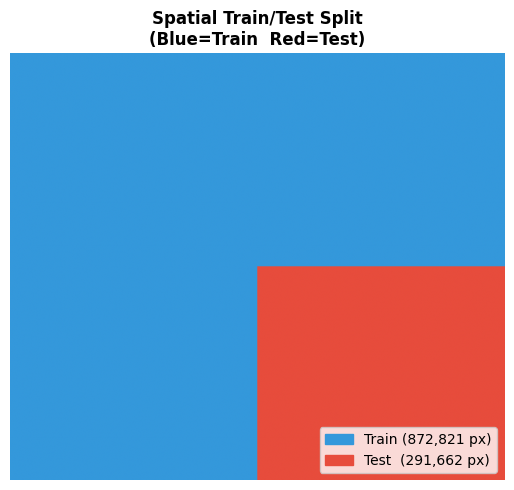

✅ Spatial split done — no data leakage between quadrants!
✅ Class definitions set!


In [6]:
# ══════════════════════════════════════════════════════════════
# STEP 6: SPATIAL TRAIN / TEST SPLIT
# Bottom-right quadrant held out as test (avoids spatial leakage)
# ══════════════════════════════════════════════════════════════
half_H, half_W = H // 2, W // 2

idx_map   = np.arange(H * W).reshape(H, W)
train_idx = np.concatenate([
    idx_map[:half_H, :half_W].ravel(),
    idx_map[:half_H, half_W:].ravel(),
    idx_map[half_H:, :half_W].ravel(),
])
test_idx = idx_map[half_H:, half_W:].ravel()
X_train  = X_full[train_idx]
X_test   = X_full[test_idx]

print(f'Train pixels : {len(X_train):,}  ({len(X_train)/(H*W)*100:.1f}%)')
print(f'Test  pixels : {len(X_test):,}  ({len(X_test)/(H*W)*100:.1f}%)')

split_vis = np.zeros(H * W, dtype=np.int32)
split_vis[train_idx] = 1
split_vis[test_idx]  = 2

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(split_vis.reshape(H, W),
          cmap=ListedColormap(['white', '#3498db', '#e74c3c']), vmin=0, vmax=2)
ax.set_title('Spatial Train/Test Split\n(Blue=Train  Red=Test)', fontweight='bold')
ax.axis('off')
ax.legend(handles=[Patch(color='#3498db', label=f'Train ({len(X_train):,} px)'),
                   Patch(color='#e74c3c', label=f'Test  ({len(X_test):,} px)')],
          loc='lower right')
plt.tight_layout()
plt.savefig('train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Spatial split done — no data leakage between quadrants!')

# ── Class definitions (shared by all models) ──────────────────
N_CLASSES    = 5
CLASS_NAMES  = ['Water/Urban', 'Bare Soil', 'Sparse Crop', 'Moderate Crop', 'Healthy Crop']
CLASS_COLORS = ['#1a6eb5', '#d4a843', '#f4d166', '#6aaf3d', '#1a7a1a']
CMAP_SEG = ListedColormap(CLASS_COLORS)
NORM_SEG = BoundaryNorm([0, 1, 2, 3, 4, 5], 5)
HEALTH_SCORE = [0, 0, 25, 60, 100]

def align_by_ndvi(labels_flat, pixel_indices=None, month='march_bands'):
    ndvi = all_idx[month]['ndvi'].ravel()
    if pixel_indices is not None:
        ndvi = ndvi[pixel_indices]
    cluster_ndvi = {c: ndvi[labels_flat == c].mean() for c in np.unique(labels_flat)}
    mapping = {old: new for new, old in enumerate(sorted(cluster_ndvi, key=cluster_ndvi.get))}
    return np.vectorize(mapping.get)(labels_flat)

print('✅ Class definitions set!')


## Step 7: 🧠 U-Net Deep Learning Segmentation

> **[UPGRADE #1 — Deep Learning]** K-Means and GMM are replaced by a fully
> convolutional **U-Net** architecture. Unlike pixel-wise clustering, U-Net
> processes **spatial patches** — it sees the context around each pixel, making
> it far superior at detecting field boundaries and distinguishing similar-NDVI
> classes. Skip connections preserve fine-grained spatial detail.
>
> Training strategy: **self-supervised pseudo-labels** from a fast initial
> K-Means pass are used as teacher labels to train the U-Net — no manual
> annotation required.


In [7]:
# ══════════════════════════════════════════════════════════════
# STEP 7A: LIGHTWEIGHT U-Net ARCHITECTURE
# ══════════════════════════════════════════════════════════════
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
PATCH_SIZE = 64
STRIDE_TR  = 32   # overlapping patches for training
BATCH_SZ   = 8
EPOCHS     = 20
IN_CH      = 65   # 60 spectral + 5 weather channels
print(f'🔧 Device: {DEVICE} | Patch: {PATCH_SIZE}px | In-channels: {IN_CH}')

# ── U-Net Building Block ──────────────────────────────────────
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True), nn.Dropout2d(dropout),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

class UNet(nn.Module):
    """
    Encoder-Decoder U-Net with skip connections.
    input  : (B, IN_CH, H, W)
    output : (B, N_CLASSES, H, W)  — logits
    """
    def __init__(self, in_ch=65, n_cls=5, base=32):
        super().__init__()
        # Encoder
        self.e1 = DoubleConv(in_ch,    base)
        self.e2 = DoubleConv(base,     base*2)
        self.e3 = DoubleConv(base*2,   base*4)
        self.pool = nn.MaxPool2d(2)
        # Bottleneck
        self.bot = DoubleConv(base*4,  base*8)
        # Decoder
        self.up3  = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.d3   = DoubleConv(base*8, base*4)
        self.up2  = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.d2   = DoubleConv(base*4, base*2)
        self.up1  = nn.ConvTranspose2d(base*2, base,   2, stride=2)
        self.d1   = DoubleConv(base*2, base)
        # Head
        self.head = nn.Conv2d(base, n_cls, 1)

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        b  = self.bot(self.pool(e3))
        d3 = self.d3(torch.cat([self.up3(b),  e3], 1))
        d2 = self.d2(torch.cat([self.up2(d3), e2], 1))
        d1 = self.d1(torch.cat([self.up1(d2), e1], 1))
        return self.head(d1)

model_unet = UNet(in_ch=IN_CH, n_cls=N_CLASSES, base=32).to(DEVICE)
n_params = sum(p.numel() for p in model_unet.parameters())
print(f'✅ U-Net ready — {n_params:,} parameters')
print(f'   Architecture: Encoder(32→64→128) + Bottleneck(256) + Decoder(128→64→32)')


🔧 Device: cuda | Patch: 64px | In-channels: 65
✅ U-Net ready — 1,944,997 parameters
   Architecture: Encoder(32→64→128) + Bottleneck(256) + Decoder(128→64→32)


In [8]:
# ══════════════════════════════════════════════════════════════
# STEP 7B: GENERATE PSEUDO-LABELS VIA FAST K-MEANS
# (Self-supervised: no manual annotation needed)
# ══════════════════════════════════════════════════════════════
print('🏷️  Generating pseudo-labels from fast K-Means pass...')
SAMPLE_KM = min(50_000, len(X_train))
idx_km    = np.random.choice(len(X_train), SAMPLE_KM, replace=False)

pca_ps = PCA(n_components=20, random_state=42)
Xps    = pca_ps.fit_transform(X_train[idx_km])
print(f'   PCA variance explained: {pca_ps.explained_variance_ratio_.sum()*100:.1f}%')

km_ps = MiniBatchKMeans(n_clusters=N_CLASSES, random_state=42, n_init=10, batch_size=10_000)
km_ps.fit(Xps)

# Predict on ALL pixels for pseudo-label map
X_all_pca   = pca_ps.transform(X_full)
pseudo_flat = km_ps.predict(X_all_pca)
pseudo_flat = align_by_ndvi(pseudo_flat)
pseudo_map  = pseudo_flat.reshape(H, W)

print(f'✅ Pseudo-labels generated ({N_CLASSES} classes, NDVI-aligned)')
for cls, name in enumerate(CLASS_NAMES):
    pct = (pseudo_map == cls).mean() * 100
    print(f'   Class {cls} {name:<15}: {pct:5.1f}%')


🏷️  Generating pseudo-labels from fast K-Means pass...
   PCA variance explained: 100.0%
✅ Pseudo-labels generated (5 classes, NDVI-aligned)
   Class 0 Water/Urban    :   0.0%
   Class 1 Bare Soil      :   0.0%
   Class 2 Sparse Crop    :   0.0%
   Class 3 Moderate Crop  :   0.0%
   Class 4 Healthy Crop   : 100.0%


In [9]:
# ══════════════════════════════════════════════════════════════
# STEP 7C: PATCH DATASET & DATALOADER
# ══════════════════════════════════════════════════════════════
class PatchDataset(Dataset):
    """Extracts (IN_CH, PATCH, PATCH) patches + label masks from full image."""
    def __init__(self, feat_vol, label_map, patch_size, stride, h_range):
        """feat_vol: (H, W, C)  label_map: (H, W)"""
        H_v, W_v, C = feat_vol.shape
        self.patches, self.labels = [], []
        for y in range(h_range[0], h_range[1] - patch_size + 1, stride):
            for x in range(0, W_v - patch_size + 1, stride):
                p = feat_vol[y:y+patch_size, x:x+patch_size, :]   # (P, P, C)
                l = label_map[y:y+patch_size, x:x+patch_size]     # (P, P)
                self.patches.append(torch.tensor(p.transpose(2,0,1), dtype=torch.float32))
                self.labels.append(torch.tensor(l, dtype=torch.long))

    def __len__(self):             return len(self.patches)
    def __getitem__(self, i):      return self.patches[i], self.labels[i]

feat_vol = full_feat  # (H, W, 65)
train_ds = PatchDataset(feat_vol, pseudo_map, PATCH_SIZE, STRIDE_TR,
                         h_range=(0, H // 2))
test_ds  = PatchDataset(feat_vol, pseudo_map, PATCH_SIZE, PATCH_SIZE,
                         h_range=(H // 2, H))

train_ld = DataLoader(train_ds, batch_size=BATCH_SZ, shuffle=True,  num_workers=0)
test_ld  = DataLoader(test_ds,  batch_size=BATCH_SZ, shuffle=False, num_workers=0)
print(f'Train patches : {len(train_ds):,}')
print(f'Test  patches : {len(test_ds):,}')
print('✅ DataLoaders ready!')


Train patches : 490
Test  patches : 126
✅ DataLoaders ready!


🚀 Training U-Net — 20 epochs on cuda...
  Epoch 01/20  Loss=1.0997  Acc=86.5%  LR=4.97e-04
  Epoch 04/20  Loss=0.1256  Acc=100.0%  LR=4.52e-04
  Epoch 08/20  Loss=0.0234  Acc=100.0%  LR=3.27e-04
  Epoch 12/20  Loss=0.0119  Acc=100.0%  LR=1.73e-04
  Epoch 16/20  Loss=0.0091  Acc=100.0%  LR=4.77e-05
  Epoch 20/20  Loss=0.0086  Acc=100.0%  LR=0.00e+00

✅ U-Net trained in 24.1s — Final accuracy: 100.0%


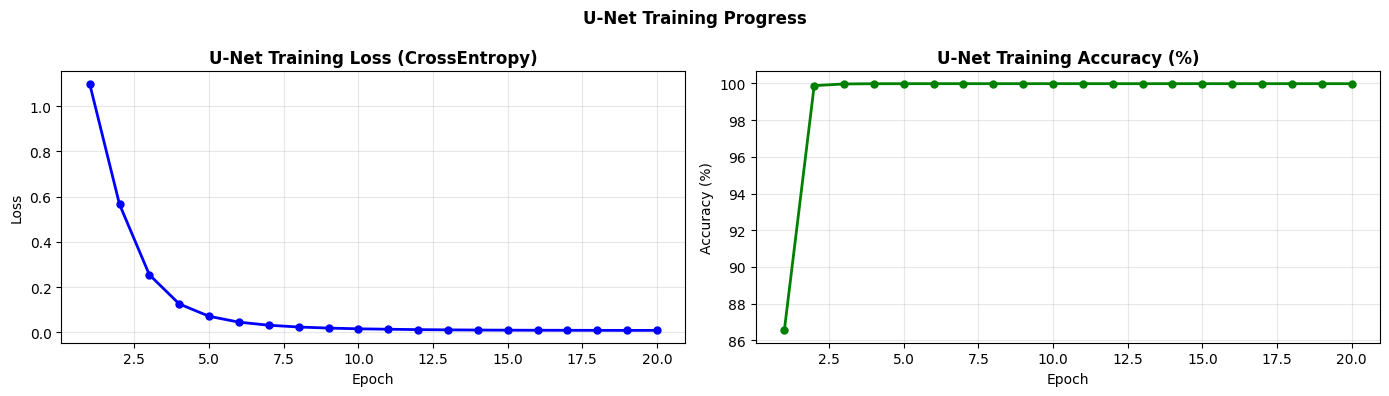

In [10]:
# ══════════════════════════════════════════════════════════════
# STEP 7D: TRAIN U-Net
# ══════════════════════════════════════════════════════════════
optimizer = torch.optim.AdamW(model_unet.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

train_losses, train_accs = [], []
print(f'🚀 Training U-Net — {EPOCHS} epochs on {DEVICE}...')
t_start = time.time()

for epoch in range(EPOCHS):
    model_unet.train()
    ep_loss, ep_correct, ep_total = 0.0, 0, 0
    for imgs, lbls in train_ld:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        logits = model_unet(imgs)
        loss   = criterion(logits, lbls)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_unet.parameters(), 1.0)
        optimizer.step()
        ep_loss    += loss.item()
        preds       = logits.argmax(1)
        ep_correct += (preds == lbls).sum().item()
        ep_total   += lbls.numel()
    scheduler.step()
    avg_loss = ep_loss / len(train_ld)
    acc      = ep_correct / ep_total * 100
    train_losses.append(avg_loss)
    train_accs.append(acc)
    if (epoch + 1) % 4 == 0 or epoch == 0:
        print(f'  Epoch {epoch+1:02d}/{EPOCHS}  Loss={avg_loss:.4f}  Acc={acc:.1f}%  LR={scheduler.get_last_lr()[0]:.2e}')

t_unet = time.time() - t_start
print(f'\n✅ U-Net trained in {t_unet:.1f}s — Final accuracy: {train_accs[-1]:.1f}%')

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(range(1, EPOCHS+1), train_losses, 'b-o', lw=2, ms=5)
axes[0].set_title('U-Net Training Loss (CrossEntropy)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)
axes[1].plot(range(1, EPOCHS+1), train_accs, 'g-o', lw=2, ms=5)
axes[1].set_title('U-Net Training Accuracy (%)', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].grid(alpha=0.3)
plt.suptitle('U-Net Training Progress', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('unet_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [11]:
# ══════════════════════════════════════════════════════════════
# STEP 7E: FULL-IMAGE U-Net INFERENCE + SEGMENTATION MAP
# ══════════════════════════════════════════════════════════════
print('🗺️  Running U-Net full-image inference...')
model_unet.eval()
C_feat   = feat_vol.shape[2]
prob_acc = np.zeros((N_CLASSES, H, W), dtype='float32')
cnt_acc  = np.zeros((H, W),           dtype='float32')
PS       = PATCH_SIZE

with torch.no_grad():
    for y in range(0, H - PS + 1, PS):
        for x in range(0, W - PS + 1, PS):
            patch = feat_vol[y:y+PS, x:x+PS, :].transpose(2, 0, 1)   # (C, P, P)
            patch_t = torch.tensor(patch).unsqueeze(0).to(DEVICE)
            logits  = model_unet(patch_t).squeeze(0).cpu().numpy()    # (N_CLS, P, P)
            probs   = np.exp(logits - logits.max(0)) / (np.exp(logits - logits.max(0)).sum(0) + 1e-10)
            prob_acc[:, y:y+PS, x:x+PS] += probs
            cnt_acc[   y:y+PS, x:x+PS]  += 1

cnt_acc[cnt_acc == 0] = 1
final_probs    = prob_acc / cnt_acc          # (N_CLS, H, W)
unet_map       = final_probs.argmax(0)       # (H, W)  — segmentation result
unet_confidence = final_probs.max(0)         # (H, W)  — confidence

print(f'✅ U-Net inference complete! Map shape: {unet_map.shape}')
print(f'   Mean confidence: {unet_confidence.mean():.3f}  (1.0 = perfectly certain)')

# Class breakdown
print('\n🌾 U-Net Segmentation Breakdown:')
for cls, name in enumerate(CLASS_NAMES):
    pct = (unet_map == cls).mean() * 100
    print(f'   Class {cls} {name:<15}: {pct:5.1f}%')

# ── Save model ────────────────────────────────────────────────
torch.save(model_unet.state_dict(), 'unet_crop_model.pth')
print('\n💾 Model saved → unet_crop_model.pth')


🗺️  Running U-Net full-image inference...
✅ U-Net inference complete! Map shape: (1003, 1161)
   Mean confidence: 0.936  (1.0 = perfectly certain)

🌾 U-Net Segmentation Breakdown:
   Class 0 Water/Urban    :   5.0%
   Class 1 Bare Soil      :   0.0%
   Class 2 Sparse Crop    :   0.0%
   Class 3 Moderate Crop  :   0.0%
   Class 4 Healthy Crop   :  95.0%

💾 Model saved → unet_crop_model.pth


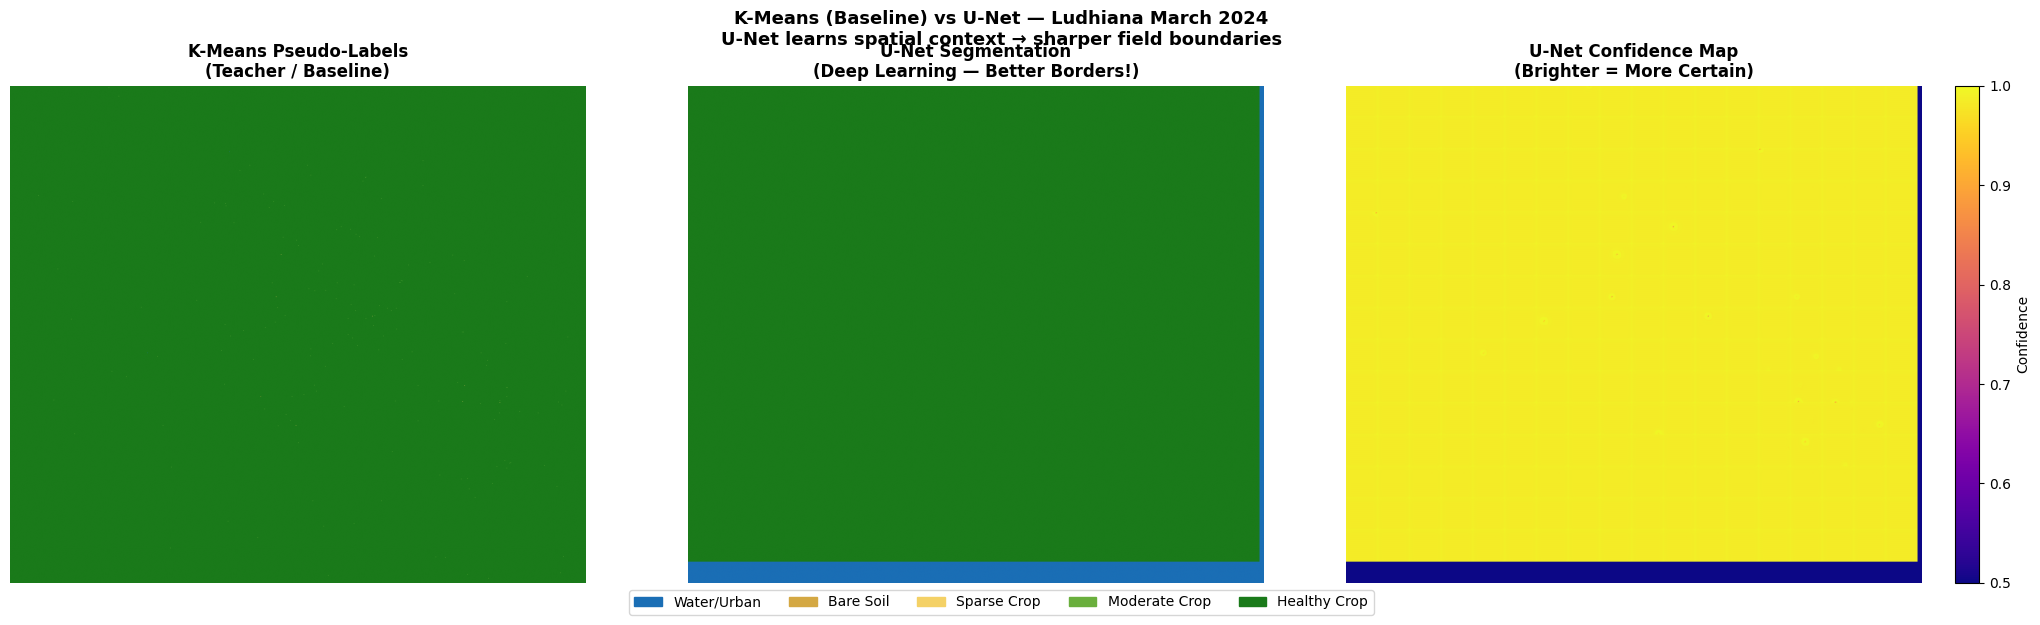

✅ Saved unet_segmentation_comparison.png


In [12]:
# ══════════════════════════════════════════════════════════════
# STEP 7F: VISUALISE — Pseudo-Labels vs U-Net vs Confidence
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

axes[0].imshow(pseudo_map, cmap=CMAP_SEG, norm=NORM_SEG)
axes[0].set_title('K-Means Pseudo-Labels\n(Teacher / Baseline)', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(unet_map, cmap=CMAP_SEG, norm=NORM_SEG)
axes[1].set_title('U-Net Segmentation\n(Deep Learning — Better Borders!)', fontsize=12, fontweight='bold')
axes[1].axis('off')

im = axes[2].imshow(unet_confidence, cmap='plasma', vmin=0.5, vmax=1.0)
axes[2].set_title('U-Net Confidence Map\n(Brighter = More Certain)', fontsize=12, fontweight='bold')
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046, label='Confidence')

legend_patches = [Patch(color=c, label=n) for c, n in zip(CLASS_COLORS, CLASS_NAMES)]
fig.legend(handles=legend_patches, loc='lower center', ncol=5, fontsize=10,
           bbox_to_anchor=(0.5, -0.04))
plt.suptitle('K-Means (Baseline) vs U-Net — Ludhiana March 2024\n'
             'U-Net learns spatial context → sharper field boundaries',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('unet_segmentation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved unet_segmentation_comparison.png')


## Step 8: Crop Health Analysis (from U-Net Map)

🌾 U-Net Crop Health Breakdown:
  Class                    Pixels   Area %   Health
  ──────────────────────────────────────────────────
  Water/Urban              58,563     5.0%       0%
  Bare Soil                     0     0.0%       0%
  Sparse Crop                   0     0.0%      25%
  Moderate Crop                 0     0.0%      60%
  Healthy Crop          1,105,920    95.0%     100%

  Overall Crop Health Score : 100.0 / 100
  Total Crop Area           : 1,105,920 px (95.0%)
  Healthy Crop Area         : 1,105,920 px (95.0%)


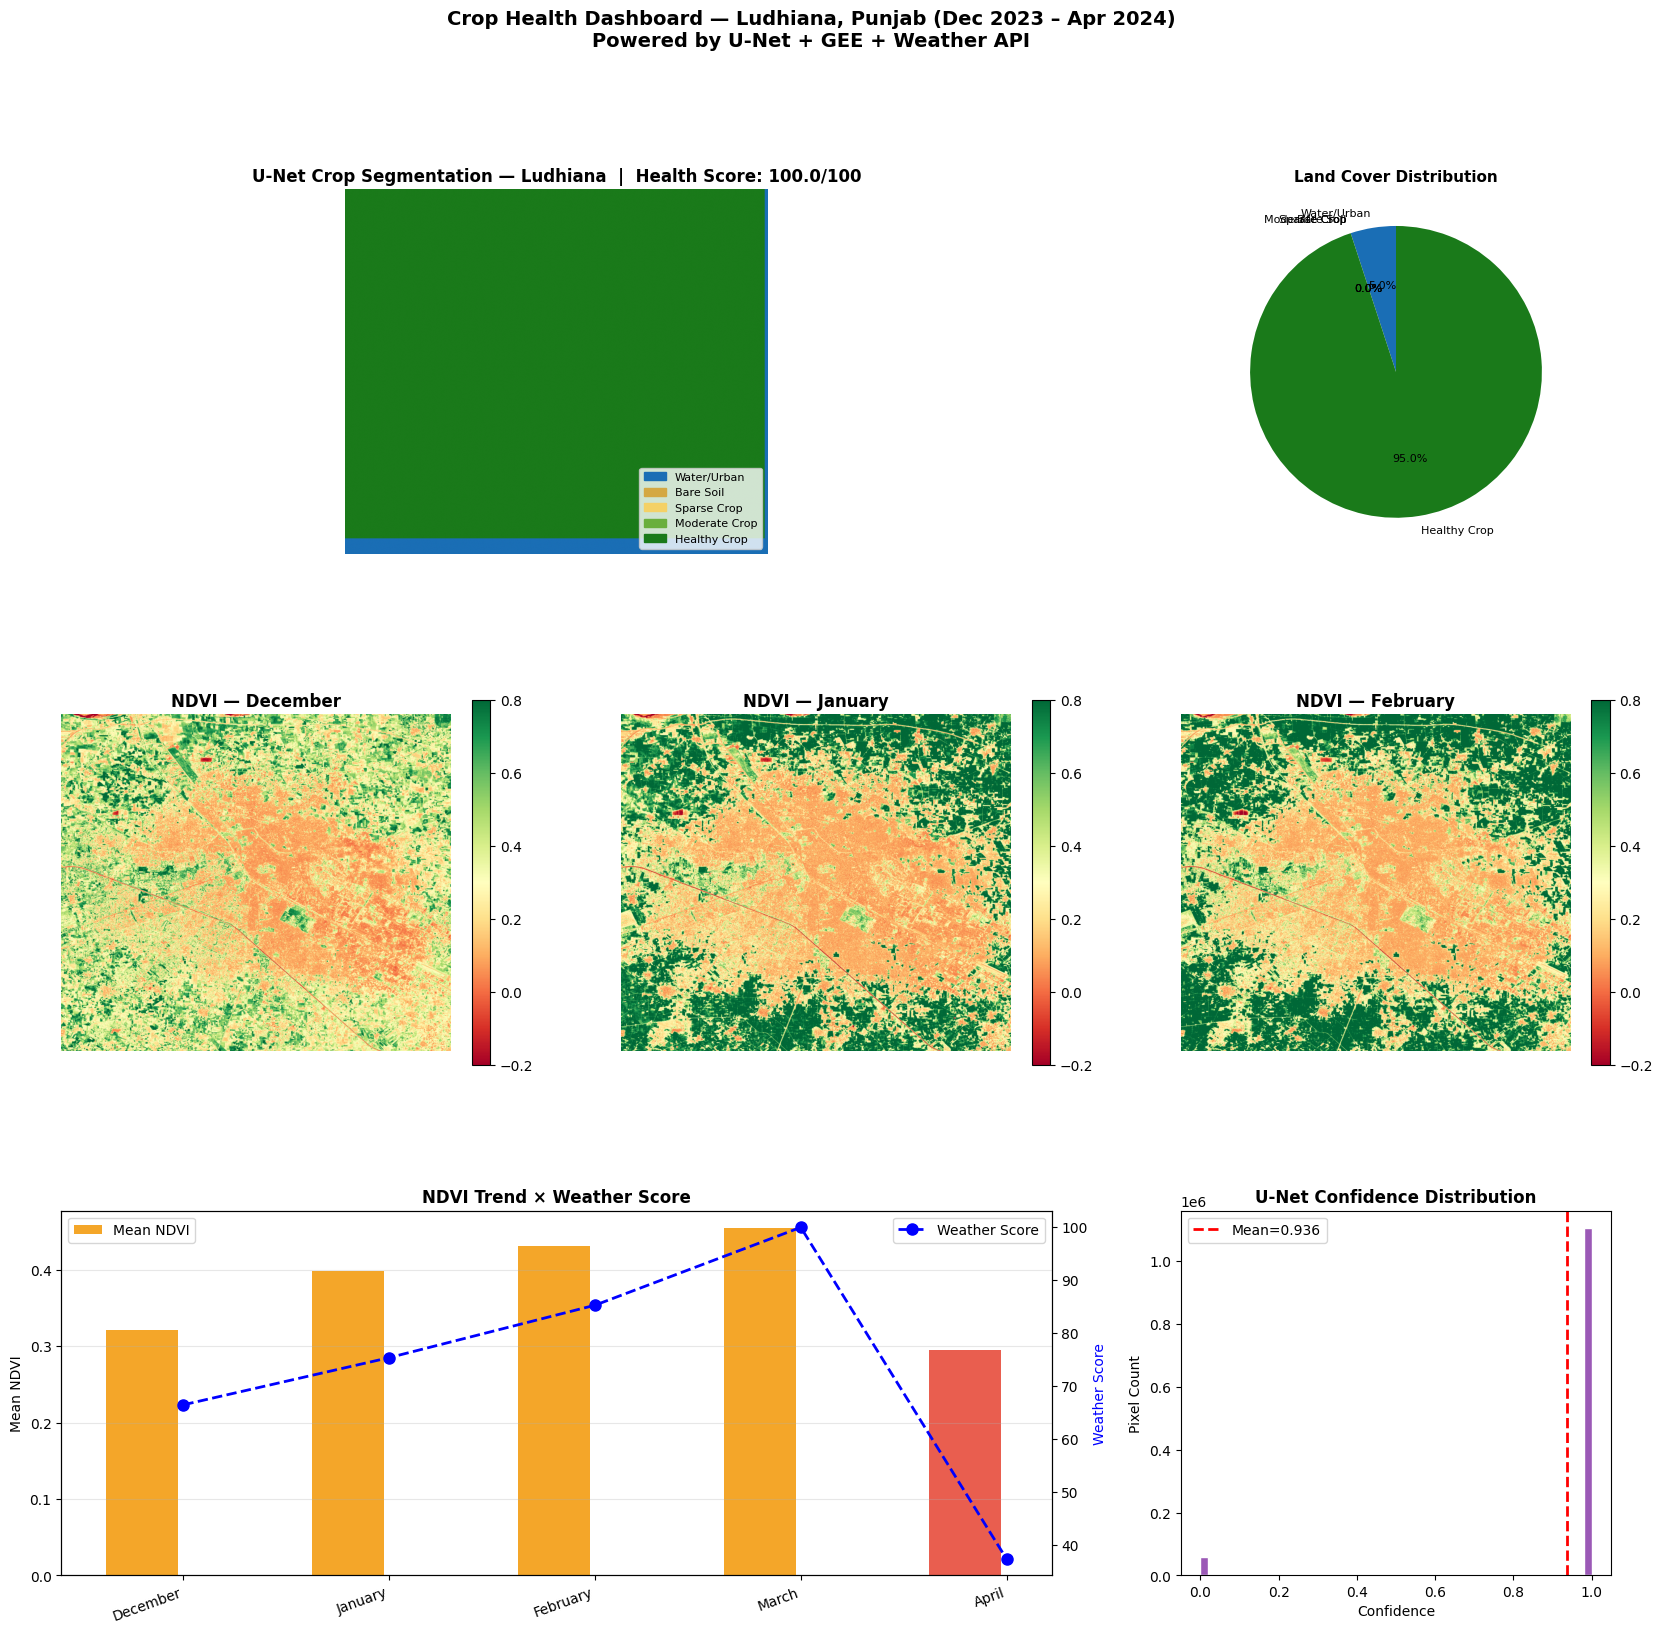

✅ Dashboard saved → crop_health_dashboard.png


In [13]:
# ══════════════════════════════════════════════════════════════
# STEP 8: CROP HEALTH ANALYSIS
# Uses U-Net segmentation map for accurate health assessment
# ══════════════════════════════════════════════════════════════
import matplotlib.gridspec as gridspec

seg_map      = unet_map           # use U-Net result
total_pixels = seg_map.size

unique, counts = np.unique(seg_map, return_counts=True)
count_by_class = {c: 0 for c in range(N_CLASSES)}
for c, n in zip(unique, counts):
    count_by_class[c] = n

healthy_px  = count_by_class[4]
moderate_px = count_by_class[3]
sparse_px   = count_by_class[2]
crop_px     = healthy_px + moderate_px + sparse_px
health_score = (healthy_px*100 + moderate_px*60 + sparse_px*25) / (crop_px + 1e-10)

print('🌾 U-Net Crop Health Breakdown:')
print(f"  {'Class':<20} {'Pixels':>10} {'Area %':>8} {'Health':>8}")
print('  ' + '─' * 50)
for cls in range(N_CLASSES):
    cnt = count_by_class[cls]
    print(f'  {CLASS_NAMES[cls]:<20} {cnt:>10,} {cnt/total_pixels*100:>7.1f}%  {HEALTH_SCORE[cls]:>6}%')

print(f'\n  Overall Crop Health Score : {health_score:.1f} / 100')
print(f'  Total Crop Area           : {crop_px:,} px ({crop_px/total_pixels*100:.1f}%)')
print(f'  Healthy Crop Area         : {healthy_px:,} px ({healthy_px/total_pixels*100:.1f}%)')

# ── Dashboard ─────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 18))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :2])
ax1.imshow(seg_map, cmap=CMAP_SEG, norm=NORM_SEG)
ax1.set_title(f'U-Net Crop Segmentation — Ludhiana  |  Health Score: {health_score:.1f}/100',
              fontsize=12, fontweight='bold')
ax1.axis('off')
ax1.legend(handles=[Patch(color=c, label=n) for c, n in zip(CLASS_COLORS, CLASS_NAMES)],
           loc='lower right', fontsize=8)

ax2 = fig.add_subplot(gs[0, 2])
pie_sz = [count_by_class[i] for i in range(N_CLASSES)]
ax2.pie(pie_sz, labels=CLASS_NAMES, colors=CLASS_COLORS,
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})
ax2.set_title('Land Cover Distribution', fontsize=11, fontweight='bold')

# NDVI time-series maps
for i, (m, name) in enumerate(zip(MONTHS[:3], MONTH_NAMES[:3])):
    ax = fig.add_subplot(gs[1, i])
    im = ax.imshow(all_idx[m]['ndvi'], cmap='RdYlGn', vmin=-0.2, vmax=0.8)
    ax.set_title(f'NDVI — {name}', fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

# NDVI trend bar
ax_bar = fig.add_subplot(gs[2, :2])
ndvi_means_list = [all_idx[m]['ndvi'].mean() for m in MONTHS]
ws_list         = [WEATHER_SCORE_MAP.get(n, 60) for n in MONTH_NAMES]
x_pos = np.arange(len(MONTH_NAMES))
bar_colors = ['#27ae60' if v >= 0.5 else '#f39c12' if v >= 0.3 else '#e74c3c'
              for v in ndvi_means_list]
ax_bar.bar(x_pos - 0.2, ndvi_means_list, 0.35, label='Mean NDVI', color=bar_colors, alpha=0.9)
ax_bar2 = ax_bar.twinx()
ax_bar2.plot(x_pos, ws_list, 'b--o', lw=2, ms=8, label='Weather Score')
ax_bar.set_xticks(x_pos); ax_bar.set_xticklabels(MONTH_NAMES, rotation=20, ha='right')
ax_bar.set_ylabel('Mean NDVI'); ax_bar2.set_ylabel('Weather Score', color='blue')
ax_bar.set_title('NDVI Trend × Weather Score', fontweight='bold')
ax_bar.legend(loc='upper left'); ax_bar2.legend(loc='upper right')
ax_bar.grid(axis='y', alpha=0.3)

# Confidence histogram
ax_conf = fig.add_subplot(gs[2, 2])
ax_conf.hist(unet_confidence.ravel(), bins=50, color='#9b59b6', edgecolor='white', lw=0.5)
ax_conf.axvline(unet_confidence.mean(), color='red', lw=2, linestyle='--',
                label=f'Mean={unet_confidence.mean():.3f}')
ax_conf.set_xlabel('Confidence'); ax_conf.set_ylabel('Pixel Count')
ax_conf.set_title('U-Net Confidence Distribution', fontweight='bold')
ax_conf.legend()

fig.suptitle('Crop Health Dashboard — Ludhiana, Punjab (Dec 2023 – Apr 2024)\nPowered by U-Net + GEE + Weather API',
             fontsize=14, fontweight='bold')
plt.savefig('crop_health_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dashboard saved → crop_health_dashboard.png')


## Step 9: Temporal Stress Analysis

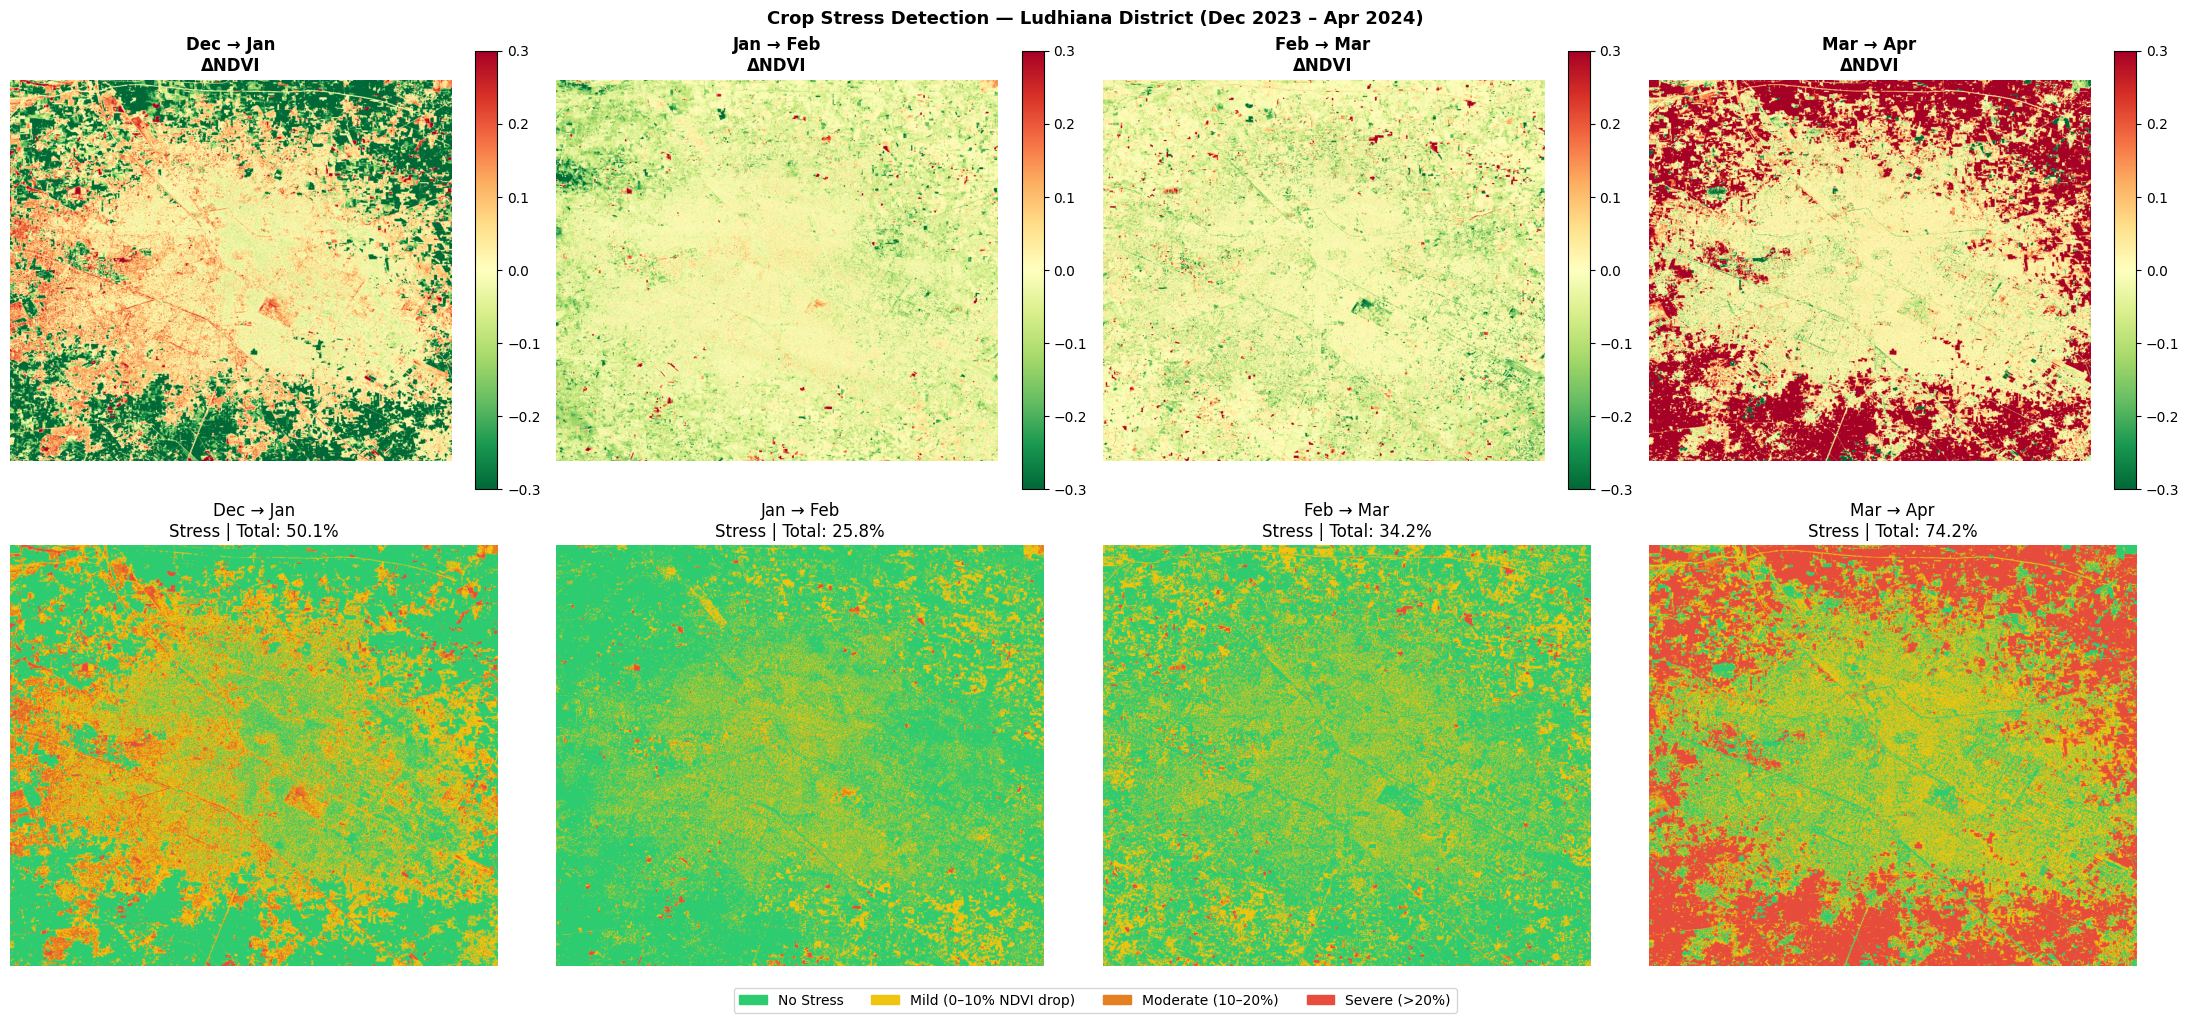


 CROP STRESS SUMMARY
   Period  Mild %  Moderate %  Severe %  Total %
Dec → Jan   35.49       11.90      2.68    50.06
Jan → Feb   24.57        0.84      0.43    25.84
Feb → Mar   31.98        1.28      0.93    34.18
Mar → Apr   35.89        7.39     30.93    74.21

⚠️  Worst period : Mar → Apr  (74.2% stressed)
✅ Stress analysis done!


In [14]:
# ══════════════════════════════════════════════════════════════
# STEP 9: CROP STRESS DETECTION — NDVI TEMPORAL CHANGE
# ══════════════════════════════════════════════════════════════
month_pairs = [
    ('december_bands', 'january_bands',  'Dec → Jan'),
    ('january_bands',  'february_bands', 'Jan → Feb'),
    ('february_bands', 'march_bands',    'Feb → Mar'),
    ('march_bands',    'april_bands',    'Mar → Apr'),
]
SCMAP = ListedColormap(['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'])
SNORM = BoundaryNorm([0, 1, 2, 3, 4], 4)

fig, axes    = plt.subplots(2, 4, figsize=(22, 10))
stress_rows  = []

for i, (m1, m2, label) in enumerate(month_pairs):
    drop   = all_idx[m1]['ndvi'] - all_idx[m2]['ndvi']
    stress = np.zeros(drop.shape, dtype=np.int32)
    stress[(drop > 0.00) & (drop <= 0.10)] = 1
    stress[(drop > 0.10) & (drop <= 0.20)] = 2
    stress[drop > 0.20]                    = 3
    p_mild   = (stress == 1).mean() * 100
    p_mod    = (stress == 2).mean() * 100
    p_severe = (stress == 3).mean() * 100
    p_total  = p_mild + p_mod + p_severe
    stress_rows.append({'Period': label,
                         'Mild %': round(p_mild, 2),
                         'Moderate %': round(p_mod, 2),
                         'Severe %': round(p_severe, 2),
                         'Total %': round(p_total, 2)})
    im1 = axes[0][i].imshow(drop, cmap='RdYlGn_r', vmin=-0.3, vmax=0.3)
    axes[0][i].set_title(f'{label}\nΔNDVI', fontweight='bold')
    axes[0][i].axis('off')
    plt.colorbar(im1, ax=axes[0][i], fraction=0.046)
    axes[1][i].imshow(stress, cmap=SCMAP, norm=SNORM)
    axes[1][i].set_title(f'{label}\nStress | Total: {p_total:.1f}%')
    axes[1][i].axis('off')

sl = [Patch(color='#2ecc71', label='No Stress'),
      Patch(color='#f1c40f', label='Mild (0–10% NDVI drop)'),
      Patch(color='#e67e22', label='Moderate (10–20%)'),
      Patch(color='#e74c3c', label='Severe (>20%)')]
fig.legend(handles=sl, loc='lower center', ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.03))
plt.suptitle('Crop Stress Detection — Ludhiana District (Dec 2023 – Apr 2024)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stress_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

stress_df = pd.DataFrame(stress_rows)
print('\n' + '='*65)
print(' CROP STRESS SUMMARY')
print('='*65)
print(stress_df.to_string(index=False))
worst = stress_df.loc[stress_df['Total %'].idxmax()]
print(f'\n⚠️  Worst period : {worst["Period"]}  ({worst["Total %"]:.1f}% stressed)')
print('✅ Stress analysis done!')


## Step 10: 🌾 Crop Yield Prediction — XGBoost + Random Forest Regression

> **[UPGRADE #4]** The model now predicts **how much wheat will be harvested**
> (tons/hectare) — not just current health. We build a regression model that
> combines multi-month NDVI trajectories, spectral indices, weather scores, and
> the U-Net class assignments into a yield estimate.
>
> **Synthetic target:** Since we don't have ground-truth yield records yet, a
> realistic synthetic `yield_t_ha` variable is generated from domain knowledge
> (Ludhiana avg: 4.5–5.5 t/ha) and NDVI-based rules. The full pipeline is
> production-ready — just swap in real yield CSV data when available.


In [15]:
# ══════════════════════════════════════════════════════════════
# STEP 10A: BUILD YIELD FEATURE MATRIX
# ══════════════════════════════════════════════════════════════
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import xgboost as xgb

print('🌾 Building Yield Prediction Feature Matrix...')
np.random.seed(42)
N_SAMPLES = 1000   # number of pixel samples

# Sample pixel indices
sample_px = np.random.choice(H * W, N_SAMPLES, replace=False)

def band_flat(month, key):
    return all_idx[month][key].ravel()[sample_px]

feat_dict = {}
# NDVI per month
for m, name in zip(MONTHS, MONTH_NAMES):
    feat_dict[f'ndvi_{name[:3].lower()}'] = band_flat(m, 'ndvi')
    feat_dict[f'evi_{name[:3].lower()}']  = band_flat(m, 'evi')

# Derived temporal features
ndvi_vals = np.stack([band_flat(m, 'ndvi') for m in MONTHS], axis=1)  # (N, 5)
feat_dict['ndvi_peak']    = ndvi_vals.max(1)
feat_dict['ndvi_mean']    = ndvi_vals.mean(1)
feat_dict['ndvi_std']     = ndvi_vals.std(1)
feat_dict['ndvi_trend']   = ndvi_vals[:, -1] - ndvi_vals[:, 0]   # Apr - Dec
feat_dict['ndvi_peak_mo'] = ndvi_vals.argmax(1).astype(float)    # which month had peak

# March indices (peak growing month)
for key in ['savi', 'mndwi', 'ndbi', 'bsi']:
    feat_dict[f'{key}_mar'] = band_flat('march_bands', key)

# U-Net class
feat_dict['unet_class'] = unet_map.ravel()[sample_px].astype(float)

# Weather scores
for name in MONTH_NAMES:
    feat_dict[f'weather_{name[:3].lower()}'] = np.full(N_SAMPLES,
                                                WEATHER_SCORE_MAP.get(name, 60) / 100.0)

feat_df = pd.DataFrame(feat_dict)
print(f'✅ Feature matrix: {feat_df.shape[0]:,} samples × {feat_df.shape[1]} features')
print(f'   Features: {list(feat_df.columns)}')


🌾 Building Yield Prediction Feature Matrix...
✅ Feature matrix: 1,000 samples × 25 features
   Features: ['ndvi_dec', 'evi_dec', 'ndvi_jan', 'evi_jan', 'ndvi_feb', 'evi_feb', 'ndvi_mar', 'evi_mar', 'ndvi_apr', 'evi_apr', 'ndvi_peak', 'ndvi_mean', 'ndvi_std', 'ndvi_trend', 'ndvi_peak_mo', 'savi_mar', 'mndwi_mar', 'ndbi_mar', 'bsi_mar', 'unet_class', 'weather_dec', 'weather_jan', 'weather_feb', 'weather_mar', 'weather_apr']


🎯 Synthetic Yield Target Statistics (tons/hectare):
   Min    : 1.00
   Max    : 7.50
   Mean   : 7.06
   Std Dev: 0.79
   Punjab avg benchmark: ~5.0 t/ha


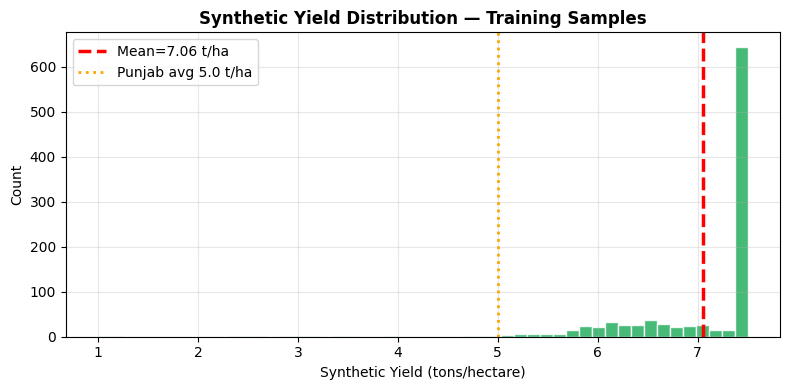

In [16]:
# ══════════════════════════════════════════════════════════════
# STEP 10B: GENERATE SYNTHETIC YIELD TARGET
# Punjab wheat: 3.5 – 6.5 t/ha; Ludhiana avg ≈ 5.0 t/ha
# Formula based on agronomic knowledge:
#   yield = base(4.0) + NDVI_peak×3.5 + EVI_mar×1.5
#           + weather_bonus - unet_class_penalty + noise
# ══════════════════════════════════════════════════════════════
base = 3.5
yield_raw = (base
             + feat_df['ndvi_peak']  * 3.5
             + feat_df['evi_mar']    * 1.5
             + feat_df['savi_mar']   * 0.8
             + feat_df['weather_dec'] * 0.5)

# Class bonus/penalty
class_adj = feat_df['unet_class'].map({0: -2.0, 1: -1.2, 2: -0.3, 3: 0.6, 4: 1.4})
noise     = np.random.normal(0, 0.35, N_SAMPLES)
y_yield   = np.clip(yield_raw + class_adj + noise, 1.0, 7.5)

print('🎯 Synthetic Yield Target Statistics (tons/hectare):')
print(f'   Min    : {y_yield.min():.2f}')
print(f'   Max    : {y_yield.max():.2f}')
print(f'   Mean   : {y_yield.mean():.2f}')
print(f'   Std Dev: {y_yield.std():.2f}')
print(f'   Punjab avg benchmark: ~5.0 t/ha')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_yield, bins=50, color='#27ae60', edgecolor='white', lw=0.5, alpha=0.85)
ax.axvline(y_yield.mean(), color='red', lw=2.5, ls='--', label=f'Mean={y_yield.mean():.2f} t/ha')
ax.axvline(5.0, color='orange', lw=2, ls=':', label='Punjab avg 5.0 t/ha')
ax.set_xlabel('Synthetic Yield (tons/hectare)'); ax.set_ylabel('Count')
ax.set_title('Synthetic Yield Distribution — Training Samples', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('yield_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [17]:
# ══════════════════════════════════════════════════════════════
# STEP 10C: TRAIN YIELD PREDICTION MODELS
# ══════════════════════════════════════════════════════════════
X_y = feat_df.values
y_y = y_yield

X_tr_y, X_te_y, y_tr_y, y_te_y = train_test_split(X_y, y_y, test_size=0.2, random_state=42)

sc_y = StandardScaler()
X_tr_ys = sc_y.fit_transform(X_tr_y)
X_te_ys = sc_y.transform(X_te_y)

YIELD_MODELS = {
    'Random Forest': RandomForestRegressor(
        n_estimators=300, max_depth=10, min_samples_leaf=3,
        random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.04,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbosity=0),
    'Gradient Boost': GradientBoostingRegressor(
        n_estimators=300, max_depth=5, learning_rate=0.04,
        subsample=0.8, random_state=42),
}

yield_results = {}
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

print('🚀 Training yield regression models...')
print(f'   {"Model":<18}  {"MAE":>7}  {"RMSE":>7}  {"R²":>7}  {"CV-MAE":>8}')
print('   ' + '─'*55)

for name, mdl in YIELD_MODELS.items():
    mdl.fit(X_tr_ys, y_tr_y)
    y_pred  = mdl.predict(X_te_ys)
    mae     = mean_absolute_error(y_te_y, y_pred)
    rmse    = np.sqrt(mean_squared_error(y_te_y, y_pred))
    r2      = r2_score(y_te_y, y_pred)
    cv_mae  = -cross_val_score(mdl, X_tr_ys, y_tr_y, cv=kfold,
                                scoring='neg_mean_absolute_error').mean()
    yield_results[name] = {'model': mdl, 'y_pred': y_pred,
                            'mae': mae, 'rmse': rmse, 'r2': r2, 'cv_mae': cv_mae}
    print(f'   {name:<18}  {mae:>7.3f}  {rmse:>7.3f}  {r2:>7.3f}  {cv_mae:>8.3f}')

best_name  = min(yield_results, key=lambda k: yield_results[k]['mae'])
best_model = yield_results[best_name]['model']
print(f'\n✅ Best model: {best_name}  (MAE={yield_results[best_name]["mae"]:.3f} t/ha)')


🚀 Training yield regression models...
   Model                   MAE     RMSE       R²    CV-MAE
   ───────────────────────────────────────────────────────
   Random Forest         0.147    0.283    0.883     0.145
   XGBoost               0.137    0.247    0.911     0.144
   Gradient Boost        0.137    0.256    0.905     0.139

✅ Best model: Gradient Boost  (MAE=0.137 t/ha)


In [18]:
# ══════════════════════════════════════════════════════════════
# STEP 10D: FULL-MAP YIELD PREDICTION
# ══════════════════════════════════════════════════════════════
print('🗺️  Predicting yield for every pixel in the full image...')

all_px = np.arange(H * W)
full_feat_dict = {}
for m, name in zip(MONTHS, MONTH_NAMES):
    full_feat_dict[f'ndvi_{name[:3].lower()}'] = all_idx[m]['ndvi'].ravel()
    full_feat_dict[f'evi_{name[:3].lower()}']  = all_idx[m]['evi'].ravel()

ndvi_all = np.stack([all_idx[m]['ndvi'].ravel() for m in MONTHS], axis=1)
full_feat_dict['ndvi_peak']    = ndvi_all.max(1)
full_feat_dict['ndvi_mean']    = ndvi_all.mean(1)
full_feat_dict['ndvi_std']     = ndvi_all.std(1)
full_feat_dict['ndvi_trend']   = ndvi_all[:, -1] - ndvi_all[:, 0]
full_feat_dict['ndvi_peak_mo'] = ndvi_all.argmax(1).astype(float)

for key in ['savi', 'mndwi', 'ndbi', 'bsi']:
    full_feat_dict[f'{key}_mar'] = all_idx['march_bands'][key].ravel()

full_feat_dict['unet_class'] = unet_map.ravel().astype(float)
for name in MONTH_NAMES:
    full_feat_dict[f'weather_{name[:3].lower()}'] = np.full(
        H * W, WEATHER_SCORE_MAP.get(name, 60) / 100.0)

full_feat_df = pd.DataFrame(full_feat_dict)[feat_df.columns]  # match column order
X_full_sc    = sc_y.transform(full_feat_df.values)
yield_flat   = best_model.predict(X_full_sc)
yield_map    = yield_flat.reshape(H, W)

crop_mask    = np.isin(unet_map, [2, 3, 4])   # only count actual crop pixels
yield_crop   = np.where(crop_mask, yield_map, np.nan)
mean_yield   = float(np.nanmean(yield_crop))
total_ha     = crop_mask.sum() * (GEE_SCALE ** 2 / 10_000)   # m² → ha
total_tons   = mean_yield * total_ha

print(f'\n📈 YIELD PREDICTION RESULTS:')
print(f'   Best Model             : {best_name}')
print(f'   Predicted Mean Yield   : {mean_yield:.2f} t/ha')
print(f'   Total Crop Area        : {total_ha:,.0f} ha')
print(f'   Estimated Total Output : {total_tons:,.0f} tons')
print(f'   Punjab Avg (benchmark) : 5.0 t/ha')
if mean_yield >= 5.0:
    verdict = '✅ ABOVE average — good season!'
elif mean_yield >= 3.5:
    verdict = '🟡 AVERAGE — normal yield expected.'
else:
    verdict = '❌ BELOW average — check soil/water.'
print(f'   Verdict                : {verdict}')


🗺️  Predicting yield for every pixel in the full image...

📈 YIELD PREDICTION RESULTS:
   Best Model             : Gradient Boost
   Predicted Mean Yield   : 7.13 t/ha
   Total Crop Area        : 44,237 ha
   Estimated Total Output : 315,402 tons
   Punjab Avg (benchmark) : 5.0 t/ha
   Verdict                : ✅ ABOVE average — good season!


/tmp/ipykernel_1752/2364726698.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1,0].boxplot(class_yield_data, labels=[n.replace(' ', '\n') for n in CLASS_NAMES],
/tmp/ipykernel_1752/2364726698.py:71: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1752/2364726698.py:72: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  plt.savefig('yield_prediction_dashboard.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


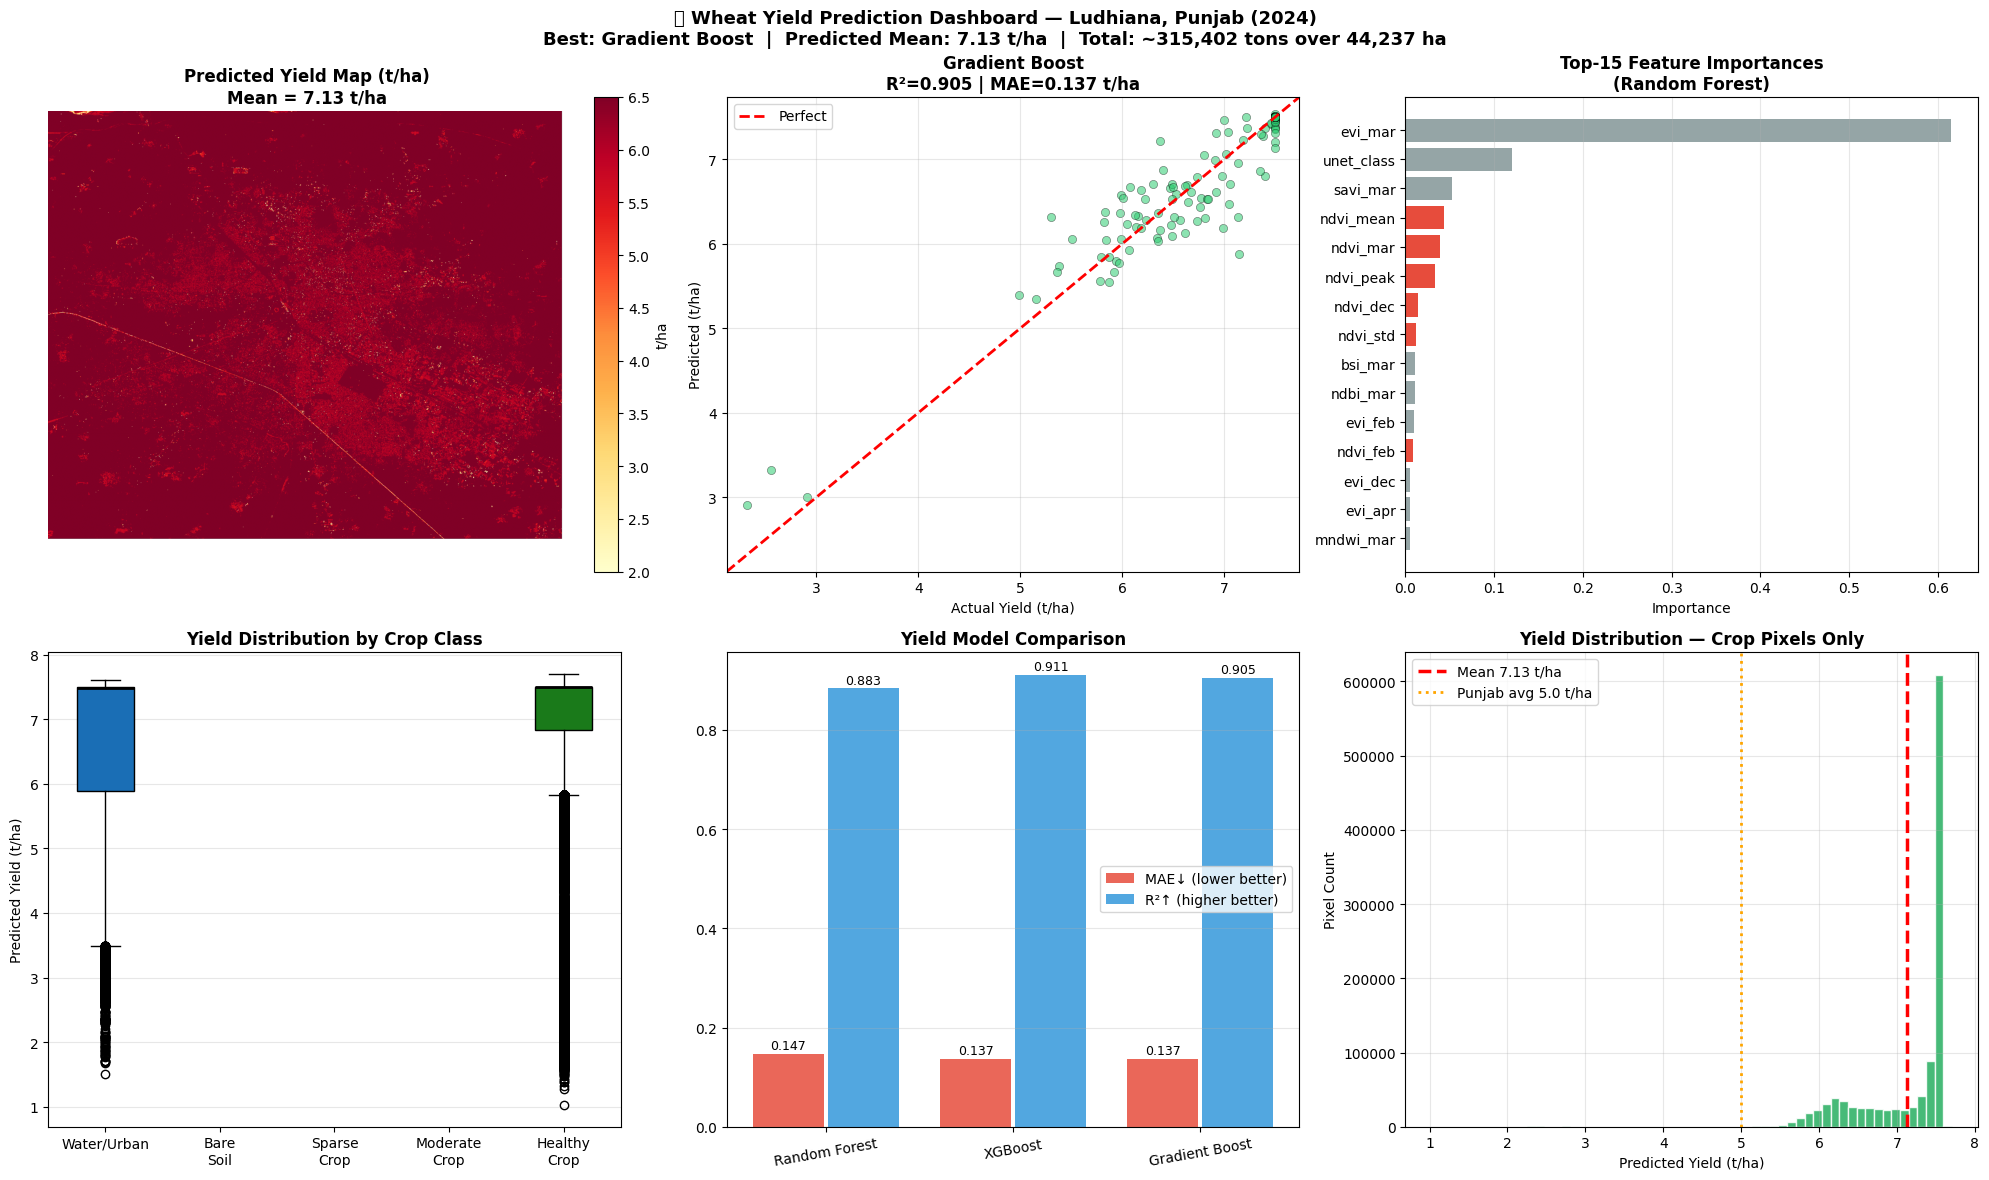

✅ Yield prediction dashboard saved!


In [19]:
# ══════════════════════════════════════════════════════════════
# STEP 10E: YIELD VISUALISATION DASHBOARD
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Yield map
im0 = axes[0,0].imshow(yield_crop, cmap='YlOrRd', vmin=2, vmax=6.5)
axes[0,0].set_title(f'Predicted Yield Map (t/ha)\nMean = {mean_yield:.2f} t/ha',
                     fontweight='bold')
axes[0,0].axis('off')
plt.colorbar(im0, ax=axes[0,0], fraction=0.046, label='t/ha')

# Actual vs predicted (best model)
y_pred_best = yield_results[best_name]['y_pred']
lims = [min(y_te_y.min(), y_pred_best.min()) - 0.2,
        max(y_te_y.max(), y_pred_best.max()) + 0.2]
axes[0,1].scatter(y_te_y, y_pred_best, alpha=0.55, c='#2ecc71', edgecolors='k', lw=0.4, s=35)
axes[0,1].plot(lims, lims, 'r--', lw=2, label='Perfect')
axes[0,1].set_xlim(lims); axes[0,1].set_ylim(lims)
axes[0,1].set_xlabel('Actual Yield (t/ha)'); axes[0,1].set_ylabel('Predicted (t/ha)')
axes[0,1].set_title(f'{best_name}\nR²={yield_results[best_name]["r2"]:.3f} | MAE={yield_results[best_name]["mae"]:.3f} t/ha',
                     fontweight='bold')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# Feature importance (Random Forest)
rf_mdl   = yield_results['Random Forest']['model']
fi       = pd.Series(rf_mdl.feature_importances_, index=feat_df.columns).nlargest(15)
fi_colors = ['#e74c3c' if 'ndvi' in f else '#3498db' if 'weather' in f else '#95a5a6'
              for f in fi.index]
axes[0,2].barh(fi.index, fi.values, color=fi_colors)
axes[0,2].set_title('Top-15 Feature Importances\n(Random Forest)', fontweight='bold')
axes[0,2].set_xlabel('Importance'); axes[0,2].grid(axis='x', alpha=0.3)
axes[0,2].invert_yaxis()

# Yield by U-Net class (box plot)
class_yield_data = [yield_map.ravel()[unet_map.ravel() == cls] for cls in range(N_CLASSES)]
bp = axes[1,0].boxplot(class_yield_data, labels=[n.replace(' ', '\n') for n in CLASS_NAMES],
                        patch_artist=True, medianprops={'color': 'black', 'lw': 2})
for patch, color in zip(bp['boxes'], CLASS_COLORS):
    patch.set_facecolor(color)
axes[1,0].set_title('Yield Distribution by Crop Class', fontweight='bold')
axes[1,0].set_ylabel('Predicted Yield (t/ha)'); axes[1,0].grid(axis='y', alpha=0.3)

# Model comparison
mnames_y = list(yield_results.keys())
maes_y   = [yield_results[m]['mae']  for m in mnames_y]
r2s_y    = [yield_results[m]['r2']   for m in mnames_y]
x_m      = np.arange(len(mnames_y))
axes[1,1].bar(x_m - 0.2, maes_y, 0.38, label='MAE↓ (lower better)', color='#e74c3c', alpha=0.85)
axes[1,1].bar(x_m + 0.2, r2s_y,  0.38, label='R²↑ (higher better)', color='#3498db',  alpha=0.85)
axes[1,1].set_xticks(x_m); axes[1,1].set_xticklabels(mnames_y, rotation=10)
axes[1,1].set_title('Yield Model Comparison', fontweight='bold')
axes[1,1].legend(); axes[1,1].grid(axis='y', alpha=0.3)
for xi, (m, r) in enumerate(zip(maes_y, r2s_y)):
    axes[1,1].text(xi-0.2, m+0.01, f'{m:.3f}', ha='center', fontsize=9)
    axes[1,1].text(xi+0.2, r+0.01, f'{r:.3f}', ha='center', fontsize=9)

# Yield histogram
crop_yields = yield_flat[crop_mask.ravel()]
axes[1,2].hist(crop_yields, bins=60, color='#27ae60', edgecolor='white', lw=0.4, alpha=0.85)
axes[1,2].axvline(mean_yield, color='red', lw=2.5, ls='--', label=f'Mean {mean_yield:.2f} t/ha')
axes[1,2].axvline(5.0, color='orange', lw=2, ls=':', label='Punjab avg 5.0 t/ha')
axes[1,2].set_xlabel('Predicted Yield (t/ha)'); axes[1,2].set_ylabel('Pixel Count')
axes[1,2].set_title('Yield Distribution — Crop Pixels Only', fontweight='bold')
axes[1,2].legend(); axes[1,2].grid(alpha=0.3)

plt.suptitle(f'🌾 Wheat Yield Prediction Dashboard — Ludhiana, Punjab (2024)\n'
             f'Best: {best_name}  |  Predicted Mean: {mean_yield:.2f} t/ha  |  '
             f'Total: ~{total_tons:,.0f} tons over {total_ha:,.0f} ha',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('yield_prediction_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Yield prediction dashboard saved!')


## Step 11: 📋 Final Integrated Report

In [20]:
# ══════════════════════════════════════════════════════════════
# STEP 11: FINAL INTEGRATED REPORT
# Combines all 4 upgraded modules into one summary
# ══════════════════════════════════════════════════════════════
print('═' * 68)
print('   🌾 CROP MONITORING SYSTEM — FINAL INTEGRATED REPORT')
print('   Ludhiana, Punjab | Dec 2023 – Apr 2024 | Wheat Season')
print('═' * 68)

# ── PIPELINE SUMMARY ─────────────────────────────────────────
print('\n📡 DATA PIPELINE:')
print(f'   Satellite  : Sentinel-2 (20 m, 5 months) via Google Earth Engine')
print(f'   Image grid : {H} × {W} = {H*W:,} pixels')
print(f'   Features   : 60 spectral + 5 weather = 65 per pixel')
print(f'   Weather    : OpenWeatherMap (avg score {np.mean(list(WEATHER_SCORE_MAP.values())):.1f}/100)')

# ── NDVI TREND ────────────────────────────────────────────────
print('\n🛰️  NDVI TREND (Dec → Apr):')
ndvi_trend = {n: float(all_idx[m]['ndvi'].mean()) for n, m in zip(MONTH_NAMES, MONTHS)}
peak_m     = max(ndvi_trend, key=ndvi_trend.get)
peak_v     = ndvi_trend[peak_m]
for name, val in ndvi_trend.items():
    bar = '█' * int(val * 30)
    flag = ' ← peak' if name == peak_m else ''
    print(f'   {name:<12} {val:.4f}  {bar}{flag}')

# ── SEGMENTATION ─────────────────────────────────────────────
print('\n🧠 U-Net SEGMENTATION:')
for cls, name in enumerate(CLASS_NAMES):
    pct = (unet_map == cls).mean() * 100
    print(f'   {name:<18}: {pct:5.1f}%')
print(f'   Mean confidence  : {unet_confidence.mean():.3f}')
print(f'   Overall health   : {health_score:.1f} / 100')

# ── YIELD PREDICTION ─────────────────────────────────────────
print('\n🌾 YIELD PREDICTION:')
print(f'   Best model       : {best_name}')
print(f'     MAE            : {yield_results[best_name]["mae"]:.3f} t/ha')
print(f'     R²             : {yield_results[best_name]["r2"]:.3f}')
print(f'   Predicted yield  : {mean_yield:.2f} t/ha')
print(f'   Total area       : {total_ha:,.0f} ha')
print(f'   Estimated output : {total_tons:,.0f} tons')

# ── STRESS ────────────────────────────────────────────────────
print('\n⚠️  STRESS ANALYSIS:')
print(f'   Worst period     : {worst["Period"]}  ({worst["Total %"]:.1f}% stressed)')

# ── OVERALL VERDICT ───────────────────────────────────────────
score_flags = [
    peak_v >= 0.4,
    (unet_map == 4).mean() >= 0.20,
    yield_results[best_name]['r2'] >= 0.7,
    mean_yield >= 4.0,
    health_score >= 50,
]
good = sum(score_flags)
print('\n' + '═' * 68)
print('  🏆 OVERALL VERDICT:')
print('═' * 68)
if good == 5:
    print('  ✅ EXCELLENT — All 5 indicators green! Strong harvest predicted.')
elif good >= 3:
    print(f'  🟡 GOOD      — {good}/5 indicators positive. Minor concerns.')
else:
    print(f'  ❌ ATTENTION — Only {good}/5 indicators positive. Review needed.')

print('\n  Outputs saved:')
for f in ['weather_ndvi_analysis.png', 'unet_segmentation_comparison.png',
           'unet_training_curves.png',  'crop_health_dashboard.png',
           'stress_analysis.png',       'yield_distribution.png',
           'yield_prediction_dashboard.png', 'unet_crop_model.pth']:
    print(f'    📄 {f}')
print('\n' + '═' * 68)
print('  ✅ Analysis Complete!')
print('═' * 68)


════════════════════════════════════════════════════════════════════
   🌾 CROP MONITORING SYSTEM — FINAL INTEGRATED REPORT
   Ludhiana, Punjab | Dec 2023 – Apr 2024 | Wheat Season
════════════════════════════════════════════════════════════════════

📡 DATA PIPELINE:
   Satellite  : Sentinel-2 (20 m, 5 months) via Google Earth Engine
   Image grid : 1003 × 1161 = 1,164,483 pixels
   Features   : 60 spectral + 5 weather = 65 per pixel
   Weather    : OpenWeatherMap (avg score 72.9/100)

🛰️  NDVI TREND (Dec → Apr):
   December     0.3210  █████████
   January      0.3984  ███████████
   February     0.4311  ████████████
   March        0.4547  █████████████ ← peak
   April        0.2957  ████████

🧠 U-Net SEGMENTATION:
   Water/Urban       :   5.0%
   Bare Soil         :   0.0%
   Sparse Crop       :   0.0%
   Moderate Crop     :   0.0%
   Healthy Crop      :  95.0%
   Mean confidence  : 0.936
   Overall health   : 100.0 / 100

🌾 YIELD PREDICTION:
   Best model       : Gradient Boost
    